In [ ]:
from transformers import AutoModel, AutoTokenizer
from conllu import parse_incr

import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cosine
from tqdm import tqdm
import random
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import spearmanr
from scipy.sparse.csgraph import minimum_spanning_tree
from Probe_analysis import StructuralProbeAnalyzer
from transformers import AutoModel, AutoTokenizer
from logitlense import PosLogitLensAnalyzer
import pandas as pd
from transformers import AutoModelForMaskedLM, AutoTokenizer
import sys
sys.path.insert(0, "/mlama")  
from dataset.reader import MLama
import torch.nn.functional as F
from visualizer import Visualizer

import warnings
warnings.filterwarnings("ignore", message=".*use_inf_as_na option is deprecated.*")
warnings.filterwarnings(
    "ignore",
    message=".*figure layout has changed to tight.*",
    category=UserWarning,
)

# BERT-en

In [2]:
viz = Visualizer()

subjects = ["COL", "GFW", "JUS", "KOP", "TYE", "ZEK"]

## Capital

In [4]:
fact_type = "Capital"
family = "BERT"
avg_analyzers = viz.build_subject_avg_causal_analyzers(subjects, fact_type, family, verbose=True)
print(avg_analyzers.keys())

Subject COL: causal_tracing_results/subject_COL/Capital/BERT
  causal_BERT_Semantic_Capital_ns0.5_n69.pkl → Semantic
  causal_BERT_Whole_Capital_ns0.5_n69.pkl → Whole
  causal_BERT_Base_Capital_ns0.5_n69.pkl → Base
  causal_BERT_Language_Capital_ns0.5_n69.pkl → Language
Subject GFW: causal_tracing_results/subject_GFW/Capital/BERT
  causal_BERT_Semantic_Capital_ns0.5_n69.pkl → Semantic
  causal_BERT_Whole_Capital_ns0.5_n69.pkl → Whole
  causal_BERT_Base_Capital_ns0.5_n69.pkl → Base
  causal_BERT_Language_Capital_ns0.5_n69.pkl → Language
Subject JUS: causal_tracing_results/subject_JUS/Capital/BERT
  causal_BERT_Semantic_Capital_ns0.5_n69.pkl → Semantic
  causal_BERT_Whole_Capital_ns0.5_n69.pkl → Whole
  causal_BERT_Base_Capital_ns0.5_n69.pkl → Base
  causal_BERT_Language_Capital_ns0.5_n69.pkl → Language
Subject KOP: causal_tracing_results/subject_KOP/Capital/BERT
  causal_BERT_Semantic_Capital_ns0.5_n69.pkl → Semantic
  causal_BERT_Whole_Capital_ns0.5_n69.pkl → Whole
  causal_BERT_Base_C

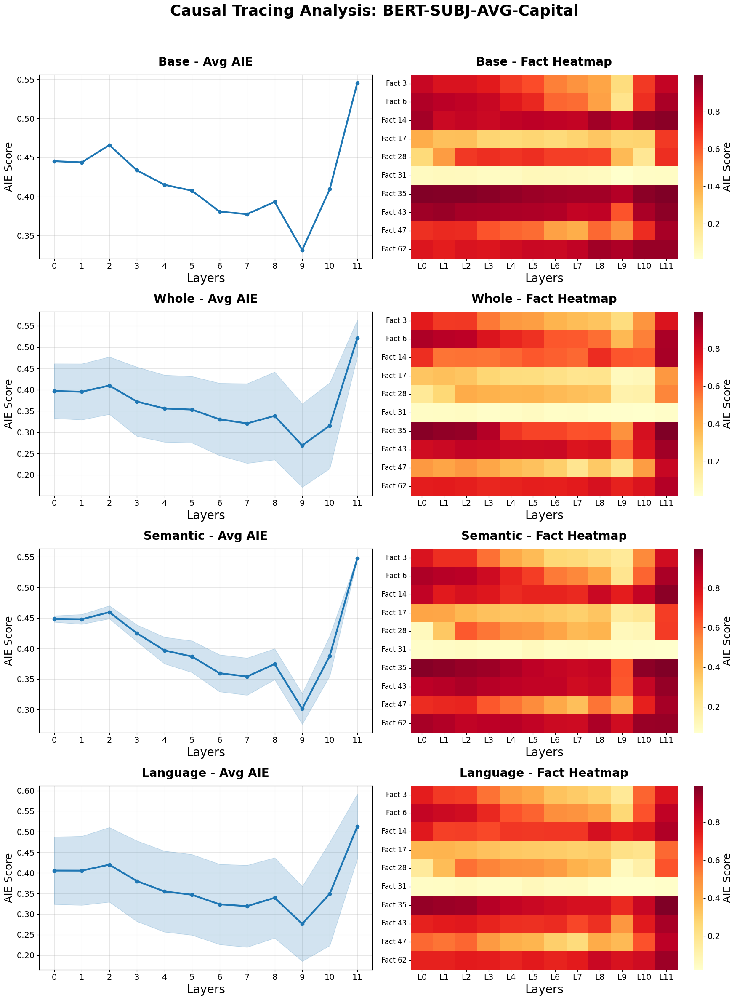

In [4]:
viz.plot_causal_family_grid_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
    random_fact_count=10
)

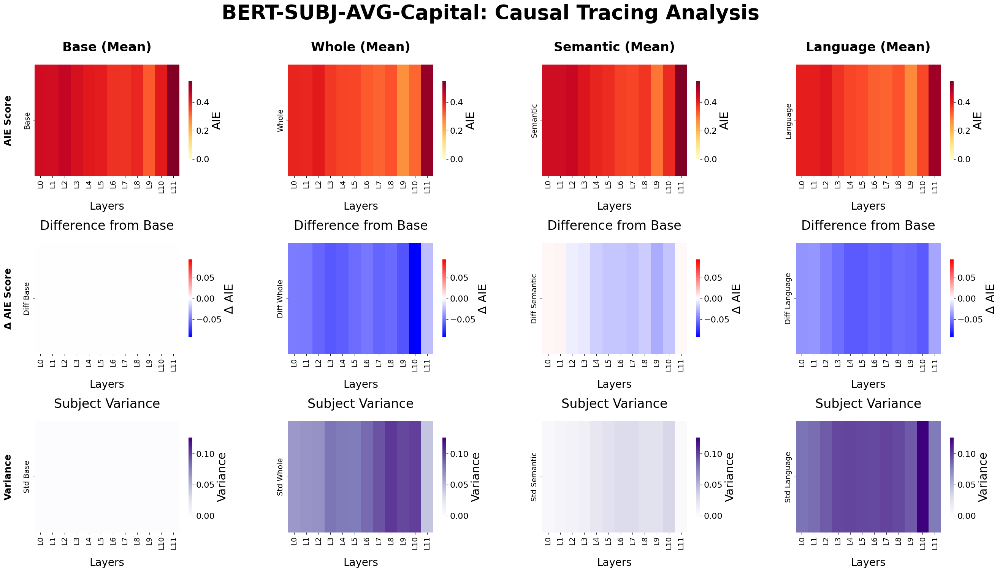

In [5]:

viz.plot_causal_family_overall_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
)

## Official Language

In [6]:
fact_type = "Official Language"
family = "BERT"
avg_analyzers = viz.build_subject_avg_causal_analyzers(subjects, fact_type, family, verbose=True)
print(avg_analyzers.keys())

Subject COL: causal_tracing_results/subject_COL/Official Language/BERT
  causal_BERT_Language_Official Language_ns0.5_n274.pkl → Language
  causal_BERT_Semantic_Official Language_ns0.5_n274.pkl → Semantic
  causal_BERT_Whole_Official Language_ns0.5_n274.pkl → Whole
  causal_BERT_Base_Official Language_ns0.5_n274.pkl → Base
Subject GFW: causal_tracing_results/subject_GFW/Official Language/BERT
  causal_BERT_Language_Official Language_ns0.5_n274.pkl → Language
  causal_BERT_Semantic_Official Language_ns0.5_n274.pkl → Semantic
  causal_BERT_Whole_Official Language_ns0.5_n274.pkl → Whole
  causal_BERT_Base_Official Language_ns0.5_n274.pkl → Base
Subject JUS: causal_tracing_results/subject_JUS/Official Language/BERT
  causal_BERT_Language_Official Language_ns0.5_n274.pkl → Language
  causal_BERT_Semantic_Official Language_ns0.5_n274.pkl → Semantic
  causal_BERT_Whole_Official Language_ns0.5_n274.pkl → Whole
  causal_BERT_Base_Official Language_ns0.5_n274.pkl → Base
Subject KOP: causal_traci

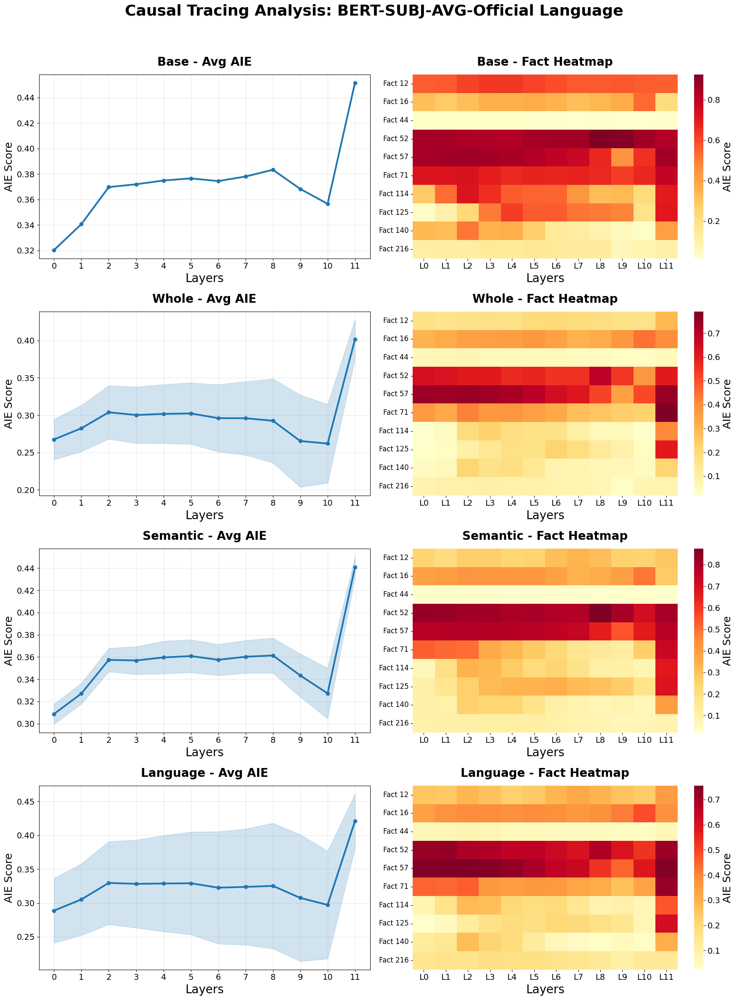

In [7]:
viz.plot_causal_family_grid_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
    random_fact_count=10
)

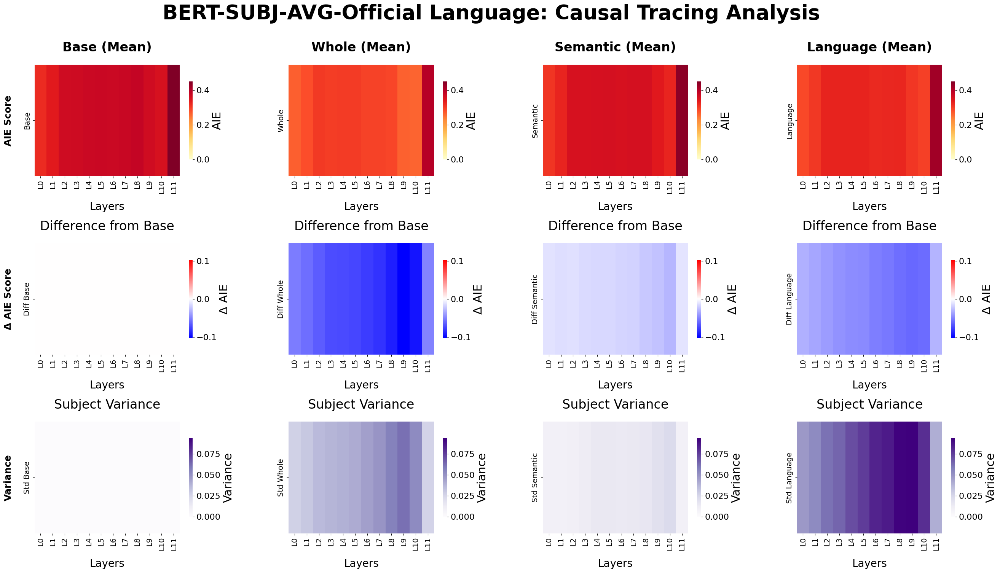

In [8]:

viz.plot_causal_family_overall_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
)

## Place of Birth

In [9]:
fact_type = "Place of Birth"
family = "BERT"
avg_analyzers = viz.build_subject_avg_causal_analyzers(subjects, fact_type, family, verbose=True)
print(avg_analyzers.keys())

Subject COL: causal_tracing_results/subject_COL/Place of Birth/BERT
  causal_BERT_Semantic_Place of Birth_ns0.5_n5.pkl → Semantic
  causal_BERT_Language_Place of Birth_ns0.5_n5.pkl → Language
  causal_BERT_Whole_Place of Birth_ns0.5_n5.pkl → Whole
  causal_BERT_Base_Place of Birth_ns0.5_n5.pkl → Base
Subject GFW: causal_tracing_results/subject_GFW/Place of Birth/BERT
  causal_BERT_Semantic_Place of Birth_ns0.5_n5.pkl → Semantic
  causal_BERT_Language_Place of Birth_ns0.5_n5.pkl → Language
  causal_BERT_Whole_Place of Birth_ns0.5_n5.pkl → Whole
  causal_BERT_Base_Place of Birth_ns0.5_n5.pkl → Base
Subject JUS: causal_tracing_results/subject_JUS/Place of Birth/BERT
  causal_BERT_Semantic_Place of Birth_ns0.5_n5.pkl → Semantic
  causal_BERT_Language_Place of Birth_ns0.5_n5.pkl → Language
  causal_BERT_Whole_Place of Birth_ns0.5_n5.pkl → Whole
  causal_BERT_Base_Place of Birth_ns0.5_n5.pkl → Base
Subject KOP: causal_tracing_results/subject_KOP/Place of Birth/BERT
  causal_BERT_Semantic_Pla

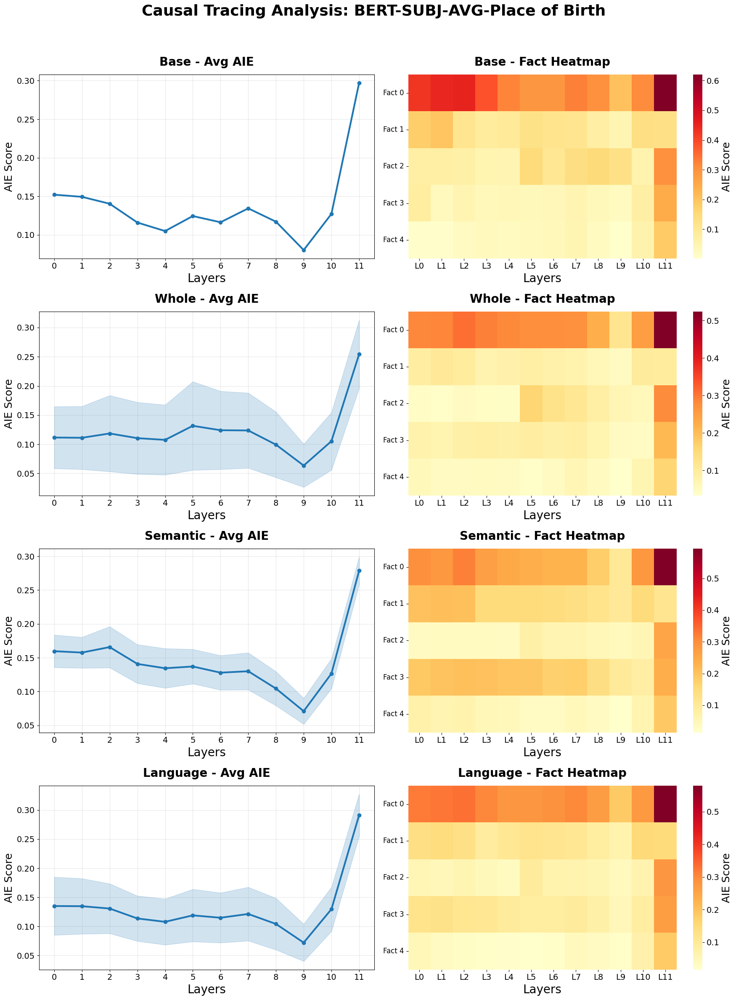

In [10]:
viz.plot_causal_family_grid_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
    random_fact_count=10
)

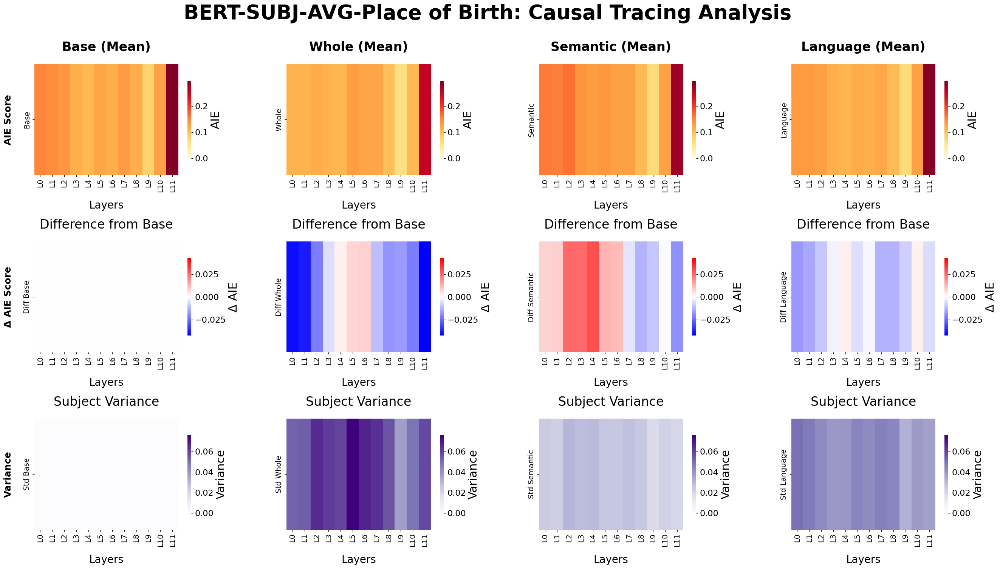

In [11]:

viz.plot_causal_family_overall_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
)

## Continent

In [12]:
fact_type = "Continent"
family = "BERT"
avg_analyzers = viz.build_subject_avg_causal_analyzers(subjects, fact_type, family, verbose=True)
print(avg_analyzers.keys())

Subject COL: causal_tracing_results/subject_COL/Continent/BERT
  causal_BERT_Semantic_Continent_ns0.5_n21.pkl → Semantic
  causal_BERT_Language_Continent_ns0.5_n21.pkl → Language
  causal_BERT_Whole_Continent_ns0.5_n21.pkl → Whole
  causal_BERT_Base_Continent_ns0.5_n21.pkl → Base
Subject GFW: causal_tracing_results/subject_GFW/Continent/BERT
  causal_BERT_Semantic_Continent_ns0.5_n21.pkl → Semantic
  causal_BERT_Language_Continent_ns0.5_n21.pkl → Language
  causal_BERT_Whole_Continent_ns0.5_n21.pkl → Whole
  causal_BERT_Base_Continent_ns0.5_n21.pkl → Base
Subject JUS: causal_tracing_results/subject_JUS/Continent/BERT
  causal_BERT_Semantic_Continent_ns0.5_n21.pkl → Semantic
  causal_BERT_Language_Continent_ns0.5_n21.pkl → Language
  causal_BERT_Whole_Continent_ns0.5_n21.pkl → Whole
  causal_BERT_Base_Continent_ns0.5_n21.pkl → Base
Subject KOP: causal_tracing_results/subject_KOP/Continent/BERT
  causal_BERT_Semantic_Continent_ns0.5_n21.pkl → Semantic
  causal_BERT_Language_Continent_ns0

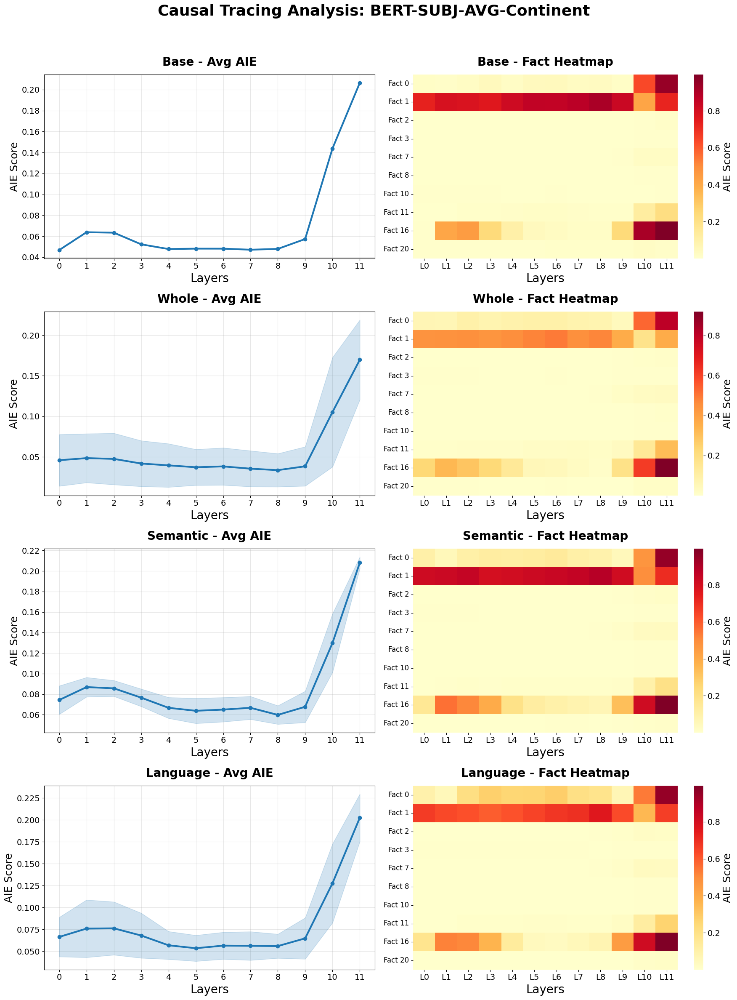

In [13]:
viz.plot_causal_family_grid_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
    random_fact_count=10
)

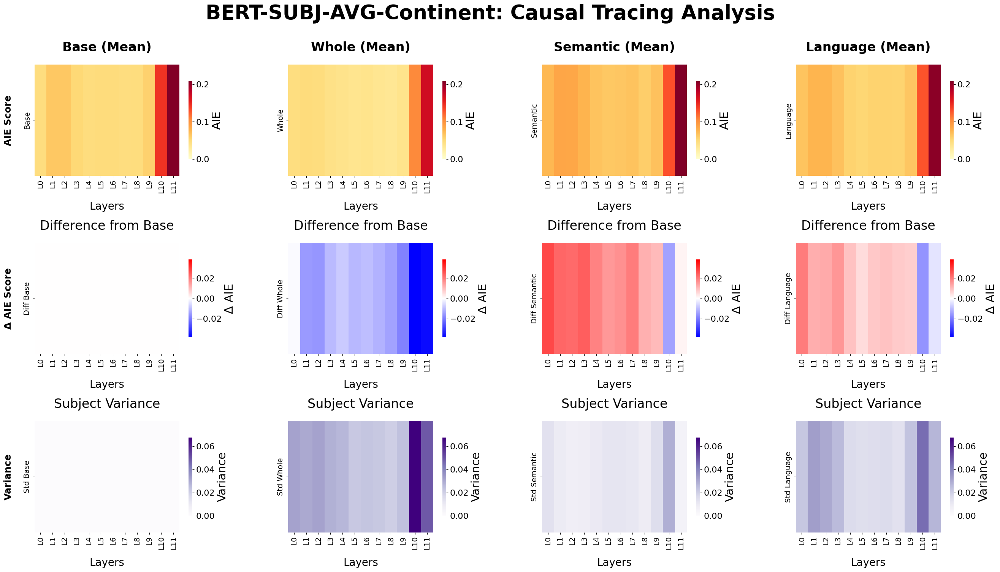

In [14]:

viz.plot_causal_family_overall_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
)

## Developer

In [15]:
fact_type = "Developer"
family = "BERT"
avg_analyzers = viz.build_subject_avg_causal_analyzers(subjects, fact_type, family, verbose=True)
print(avg_analyzers.keys())

Subject COL: causal_tracing_results/subject_COL/Developer/BERT
  causal_BERT_Semantic_Developer_ns0.5_n89.pkl → Semantic
  causal_BERT_Language_Developer_ns0.5_n89.pkl → Language
  causal_BERT_Base_Developer_ns0.5_n89.pkl → Base
  causal_BERT_Whole_Developer_ns0.5_n89.pkl → Whole
Subject GFW: causal_tracing_results/subject_GFW/Developer/BERT
  causal_BERT_Semantic_Developer_ns0.5_n89.pkl → Semantic
  causal_BERT_Language_Developer_ns0.5_n89.pkl → Language
  causal_BERT_Base_Developer_ns0.5_n89.pkl → Base
  causal_BERT_Whole_Developer_ns0.5_n89.pkl → Whole
Subject JUS: causal_tracing_results/subject_JUS/Developer/BERT
  causal_BERT_Semantic_Developer_ns0.5_n89.pkl → Semantic
  causal_BERT_Language_Developer_ns0.5_n89.pkl → Language
  causal_BERT_Base_Developer_ns0.5_n89.pkl → Base
  causal_BERT_Whole_Developer_ns0.5_n89.pkl → Whole
Subject KOP: causal_tracing_results/subject_KOP/Developer/BERT
  causal_BERT_Semantic_Developer_ns0.5_n89.pkl → Semantic
  causal_BERT_Language_Developer_ns0

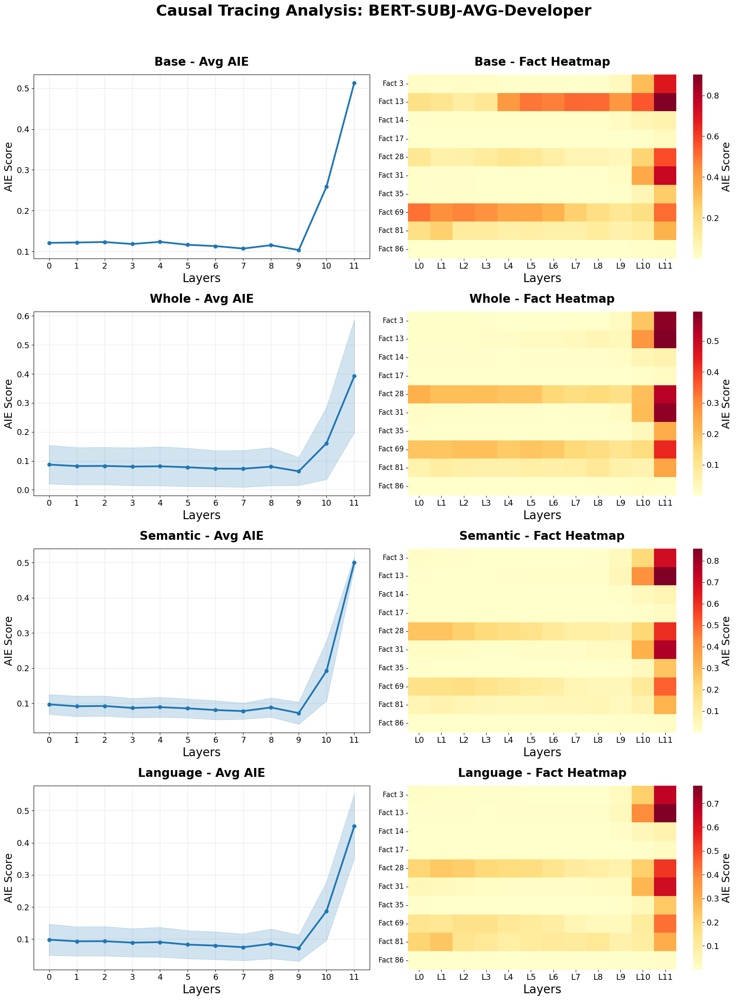

In [16]:
viz.plot_causal_family_grid_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
    random_fact_count=10
)

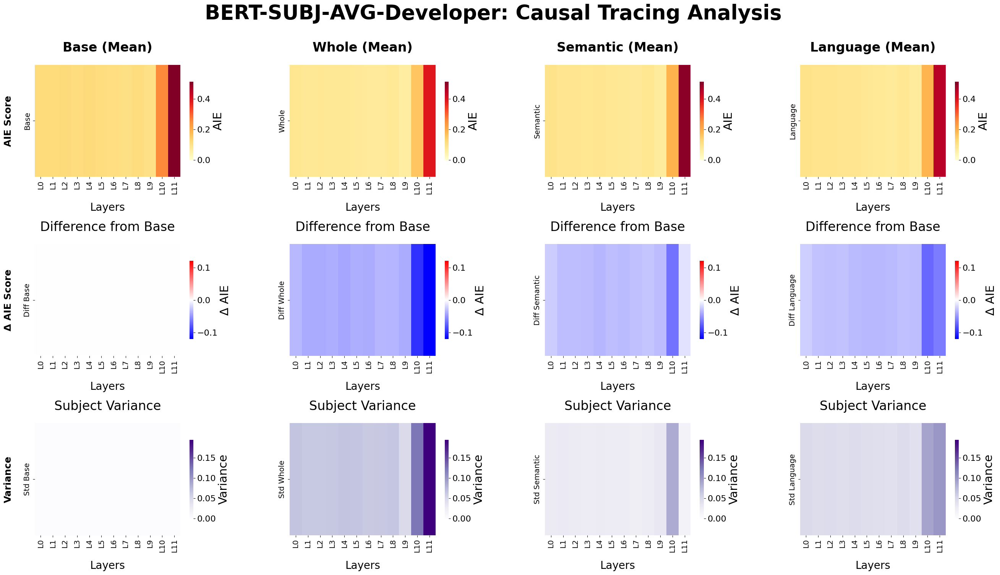

In [17]:

viz.plot_causal_family_overall_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
)

# mBERT-en

In [3]:
fact_type = "Capital"
family = "mBERT"

In [ ]:
avg_analyzers = viz.build_subject_avg_causal_analyzers(subjects, fact_type, family, verbose=True)
print(avg_analyzers.keys())

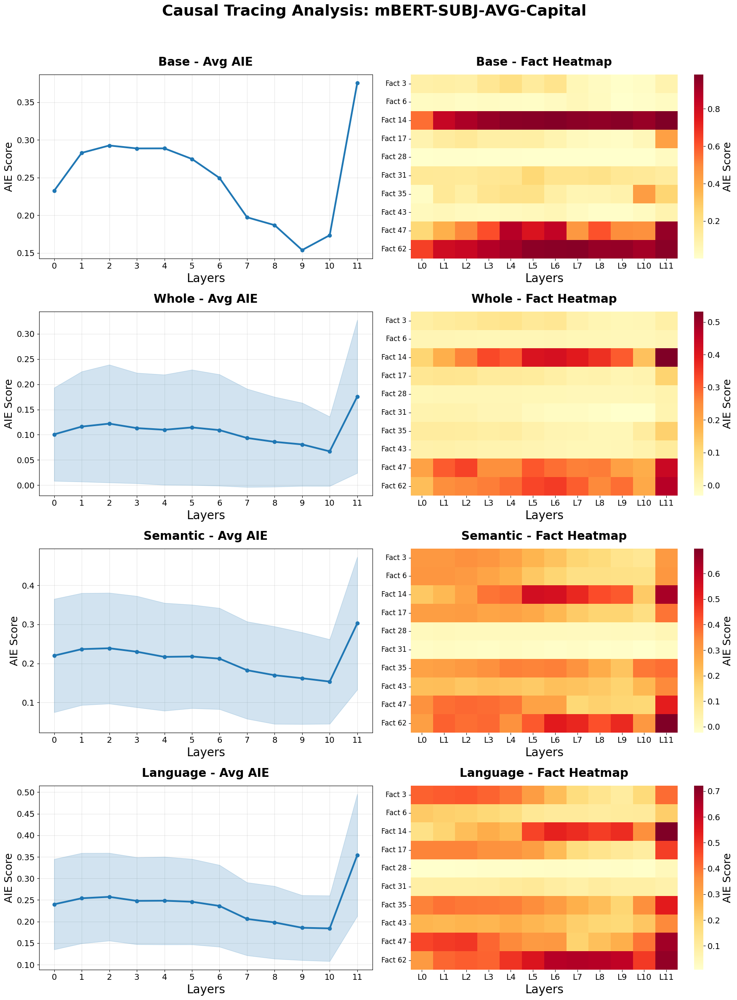

In [4]:
viz.plot_causal_family_grid_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
    random_fact_count=10
)

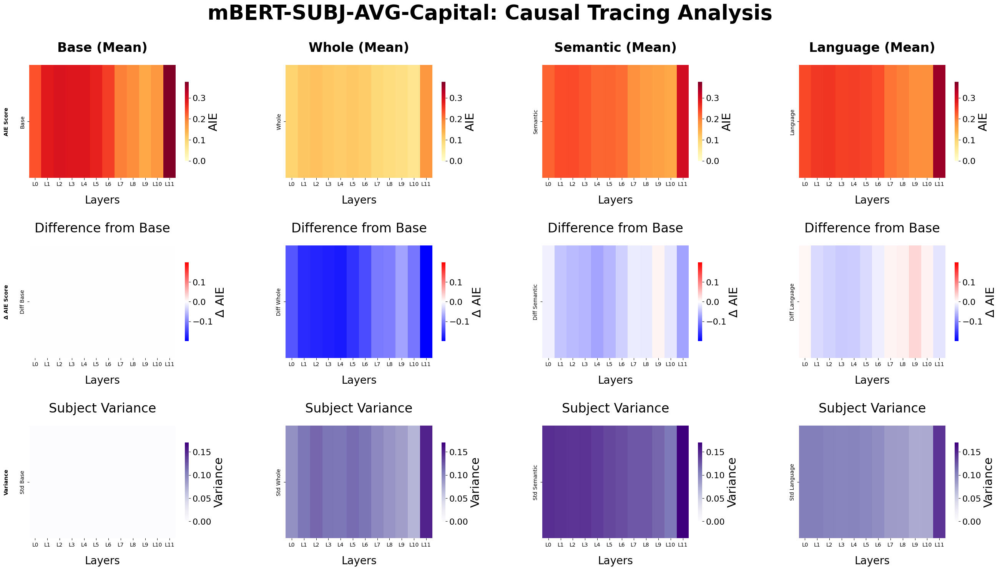

In [5]:

viz.plot_causal_family_overall_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
)

In [3]:
fact_type = "Official Language"
family = "mBERT"

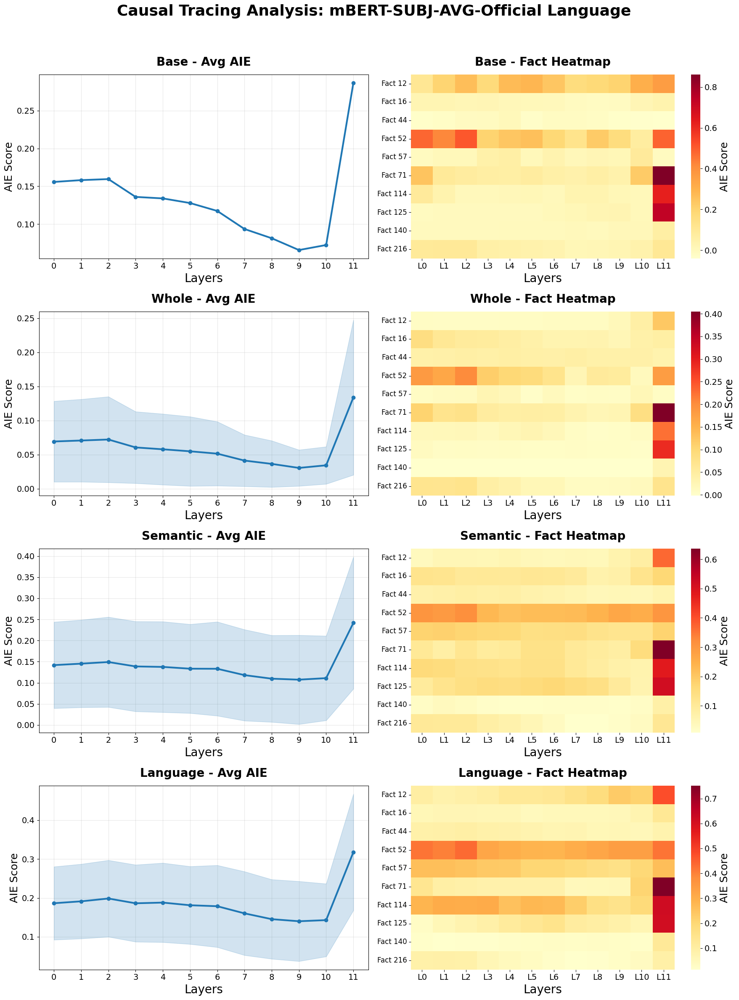

In [5]:
viz.plot_causal_family_grid_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
    random_fact_count=10
)

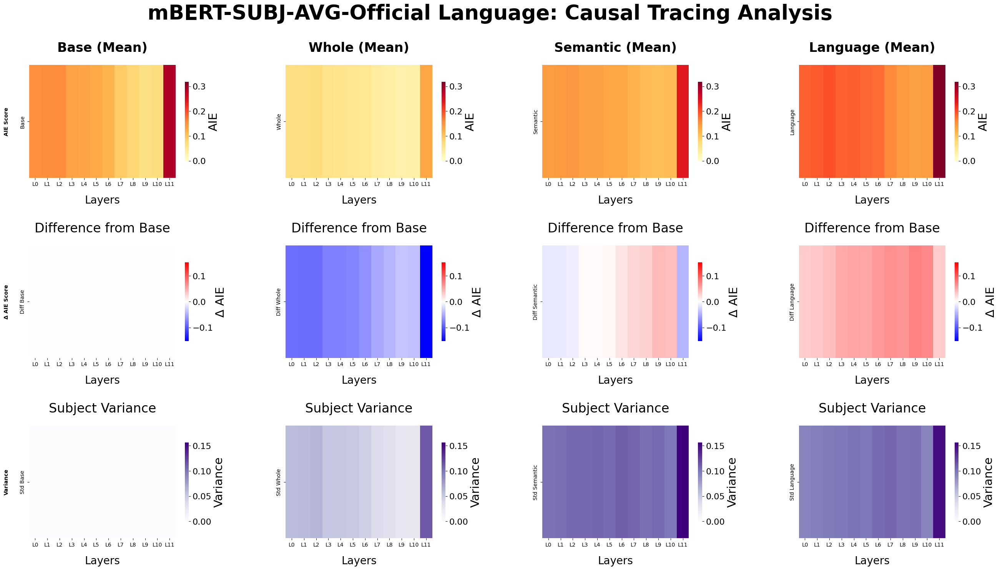

In [4]:

viz.plot_causal_family_overall_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
)

In [3]:
fact_type = "Place of Birth"
family = "mBERT"

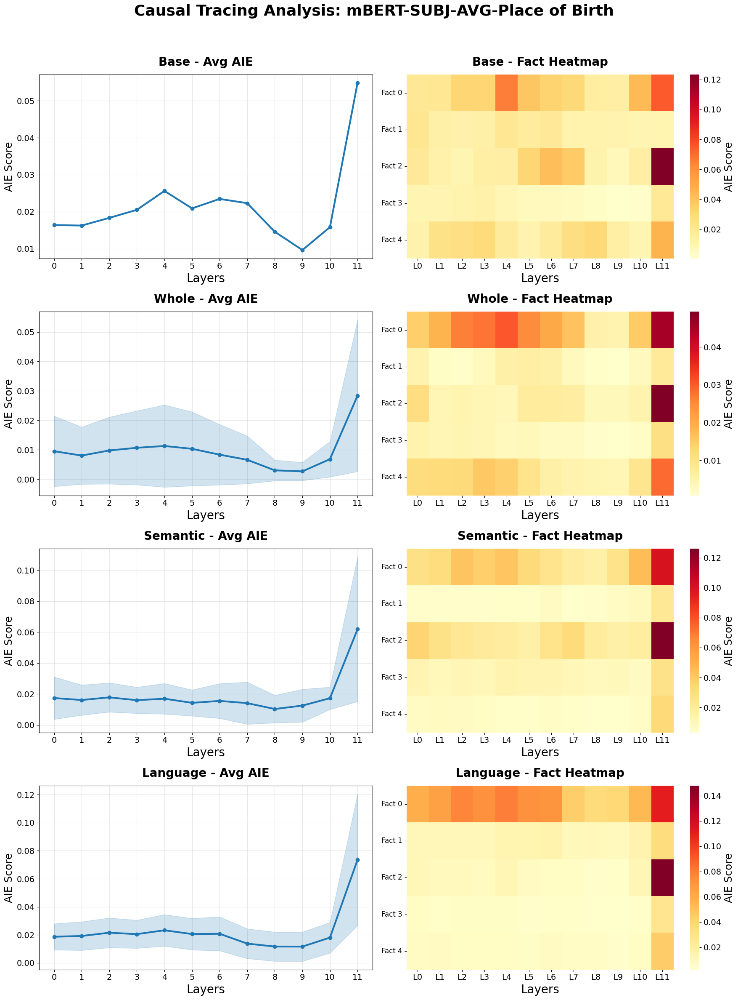

In [4]:
viz.plot_causal_family_grid_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
    random_fact_count=10
)

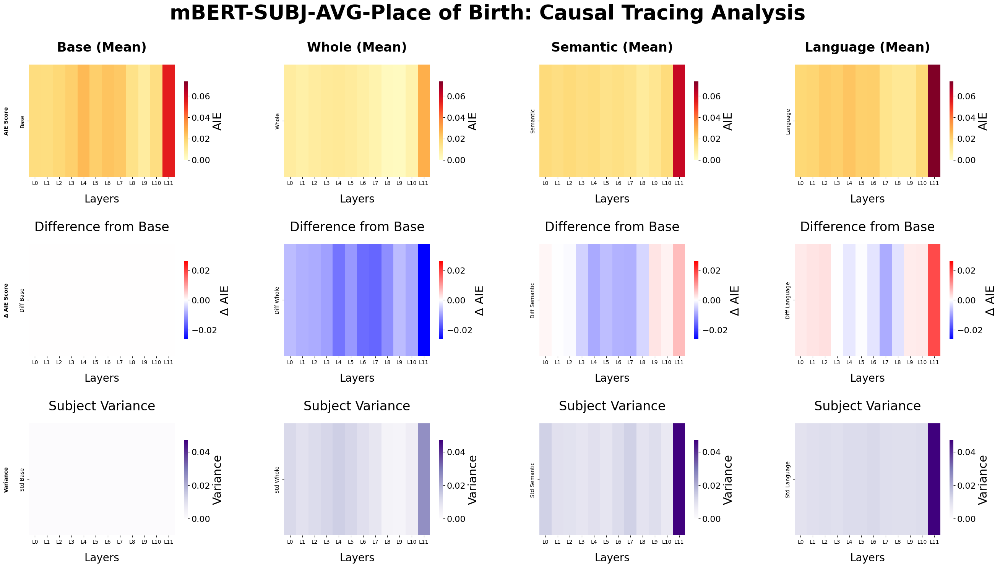

In [4]:

viz.plot_causal_family_overall_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
)

In [3]:
fact_type = "Continent"
family = "mBERT"

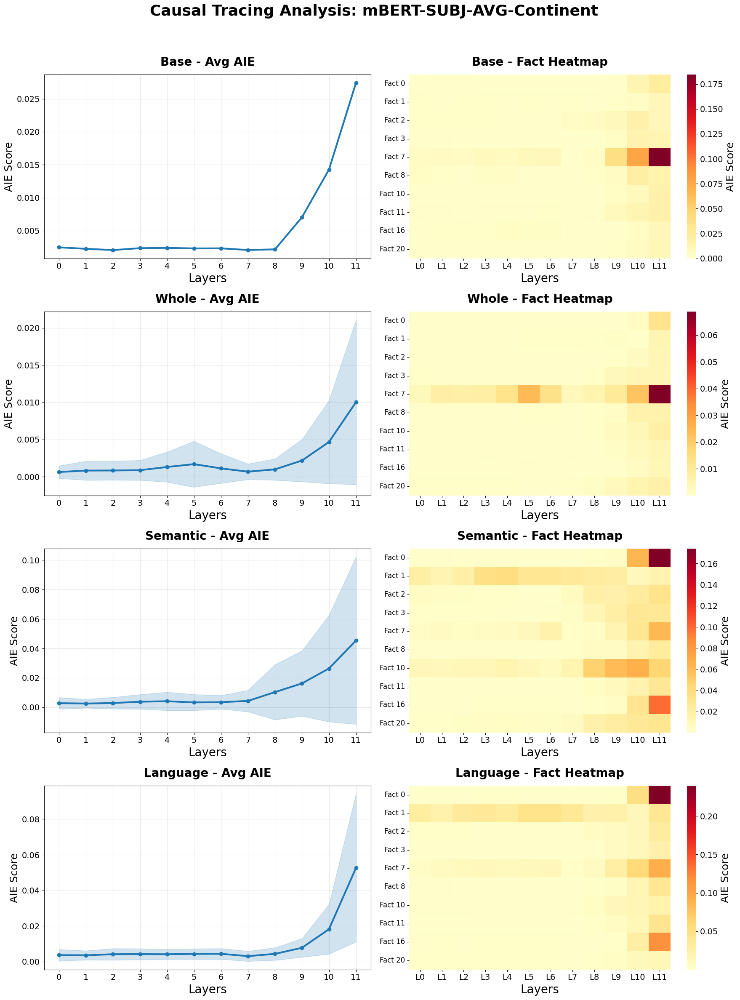

In [4]:
viz.plot_causal_family_grid_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
    random_fact_count=10
)

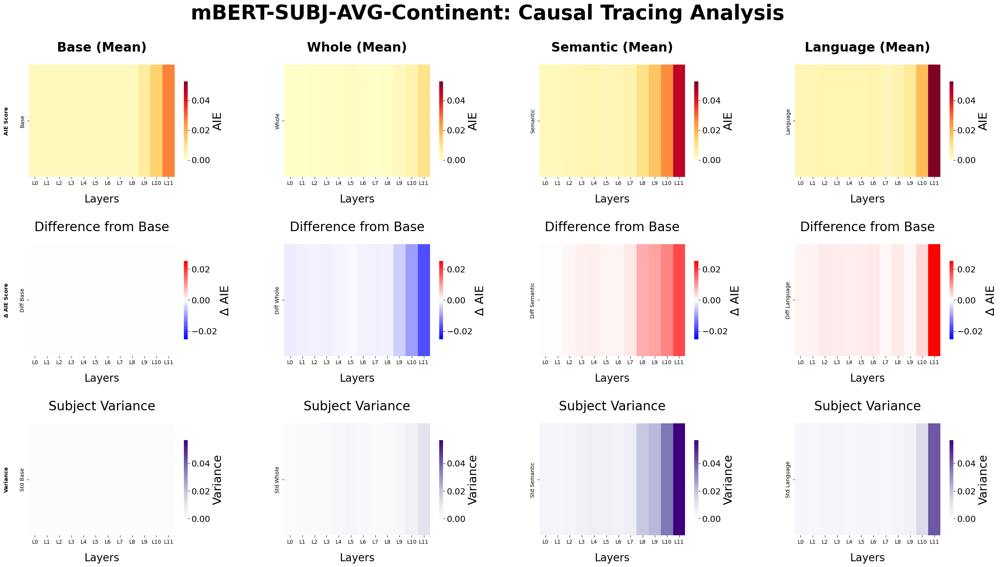

In [4]:

viz.plot_causal_family_overall_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
)

In [3]:
fact_type = "Developer"
family = "mBERT"

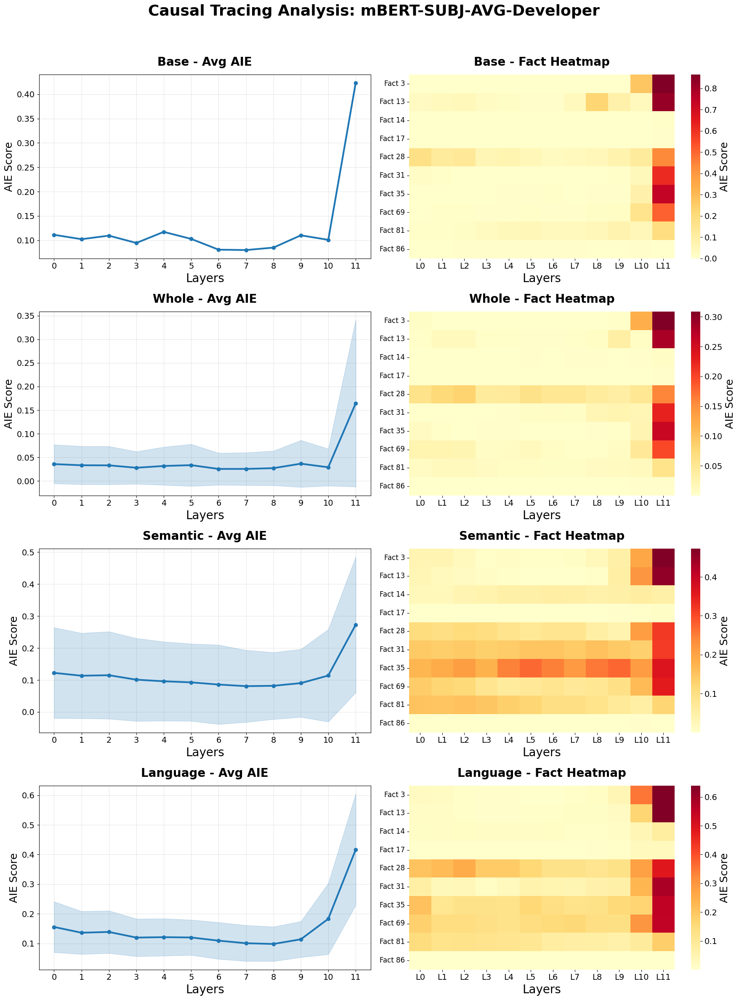

In [4]:
viz.plot_causal_family_grid_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
    random_fact_count=10
)

In [ ]:

viz.plot_causal_family_overall_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
)

# BERT-zh

In [4]:
fact_type = "Capital"
family = "BERT-ZH"
avg_analyzers = viz.build_subject_avg_causal_analyzers(subjects, fact_type, family, verbose=True)
print(avg_analyzers.keys())

Subject COL: causal_tracing_results/subject_COL/Capital/BERT-ZH
  causal_BERT-ZH_Whole_Capital_ns0.5_n69.pkl → Whole
  causal_BERT-ZH_Language_Capital_ns0.5_n69.pkl → Language
  causal_BERT-ZH_Base_Capital_ns0.5_n69.pkl → Base
  causal_BERT-ZH_Semantic_Capital_ns0.5_n69.pkl → Semantic
Subject GFW: causal_tracing_results/subject_GFW/Capital/BERT-ZH
  causal_BERT-ZH_Whole_Capital_ns0.5_n69.pkl → Whole
  causal_BERT-ZH_Language_Capital_ns0.5_n69.pkl → Language
  causal_BERT-ZH_Base_Capital_ns0.5_n69.pkl → Base
  causal_BERT-ZH_Semantic_Capital_ns0.5_n69.pkl → Semantic
Subject JUS: causal_tracing_results/subject_JUS/Capital/BERT-ZH
  causal_BERT-ZH_Whole_Capital_ns0.5_n69.pkl → Whole
  causal_BERT-ZH_Language_Capital_ns0.5_n69.pkl → Language
  causal_BERT-ZH_Base_Capital_ns0.5_n69.pkl → Base
  causal_BERT-ZH_Semantic_Capital_ns0.5_n69.pkl → Semantic
Subject KOP: causal_tracing_results/subject_KOP/Capital/BERT-ZH
  causal_BERT-ZH_Whole_Capital_ns0.5_n69.pkl → Whole
  causal_BERT-ZH_Language

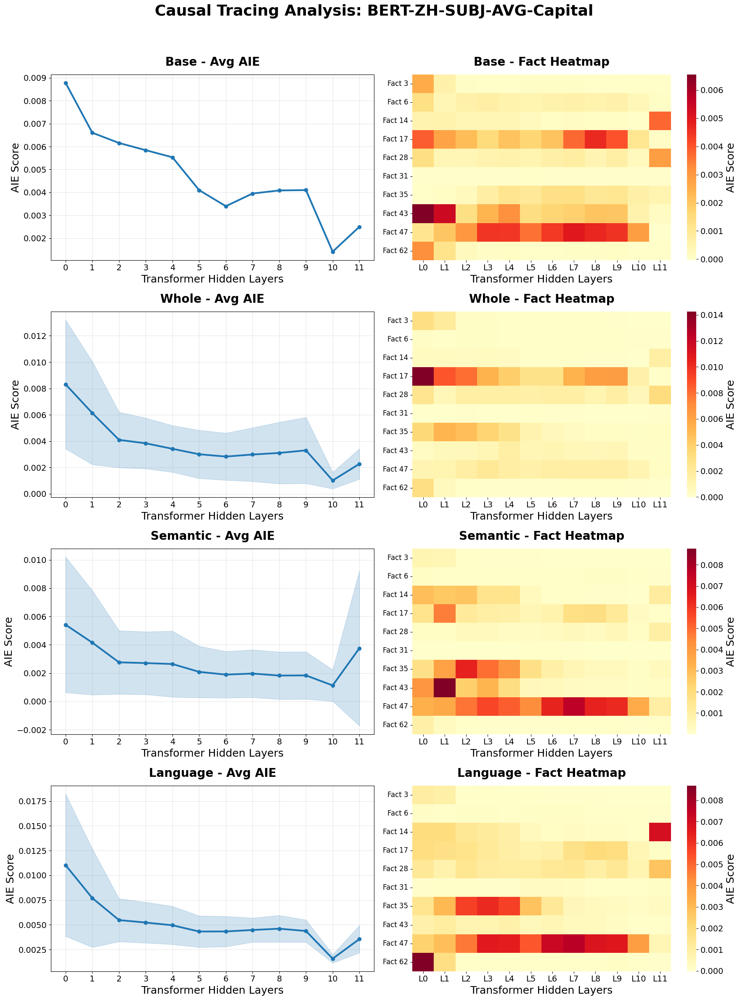

In [5]:
viz.plot_causal_family_grid_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
    random_fact_count=10
)

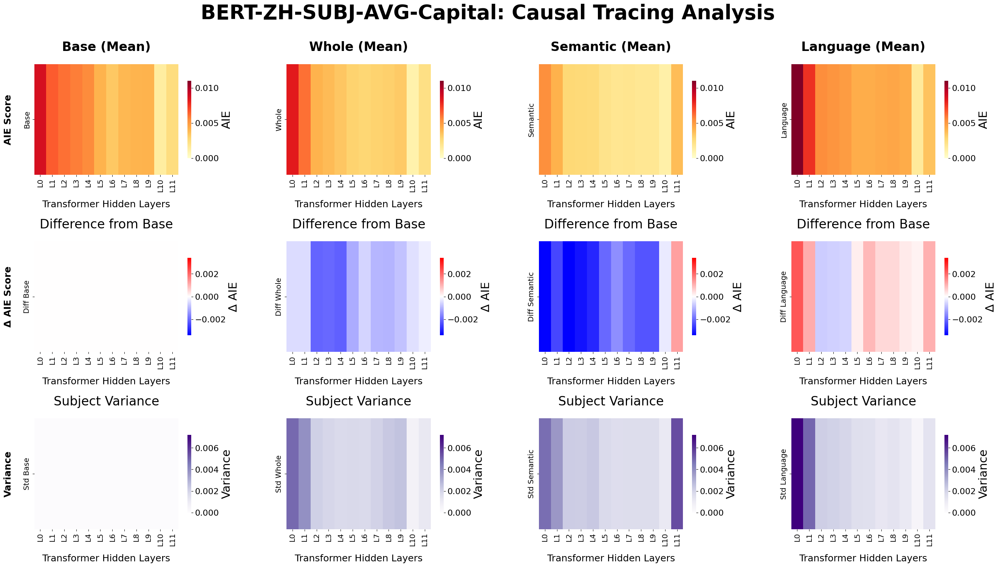

In [6]:

viz.plot_causal_family_overall_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
)

In [7]:
fact_type = "Official Language"
family = "BERT-ZH"
avg_analyzers = viz.build_subject_avg_causal_analyzers(subjects, fact_type, family, verbose=True)
print(avg_analyzers.keys())

Subject COL: causal_tracing_results/subject_COL/Official Language/BERT-ZH
  causal_BERT-ZH_Language_Official Language_ns0.5_n274.pkl → Language
  causal_BERT-ZH_Semantic_Official Language_ns0.5_n274.pkl → Semantic
  causal_BERT-ZH_Whole_Official Language_ns0.5_n274.pkl → Whole
  causal_BERT-ZH_Base_Official Language_ns0.5_n274.pkl → Base
Subject GFW: causal_tracing_results/subject_GFW/Official Language/BERT-ZH
  causal_BERT-ZH_Language_Official Language_ns0.5_n274.pkl → Language
  causal_BERT-ZH_Semantic_Official Language_ns0.5_n274.pkl → Semantic
  causal_BERT-ZH_Whole_Official Language_ns0.5_n274.pkl → Whole
  causal_BERT-ZH_Base_Official Language_ns0.5_n274.pkl → Base
Subject JUS: causal_tracing_results/subject_JUS/Official Language/BERT-ZH
  causal_BERT-ZH_Language_Official Language_ns0.5_n274.pkl → Language
  causal_BERT-ZH_Semantic_Official Language_ns0.5_n274.pkl → Semantic
  causal_BERT-ZH_Whole_Official Language_ns0.5_n274.pkl → Whole
  causal_BERT-ZH_Base_Official Language_ns

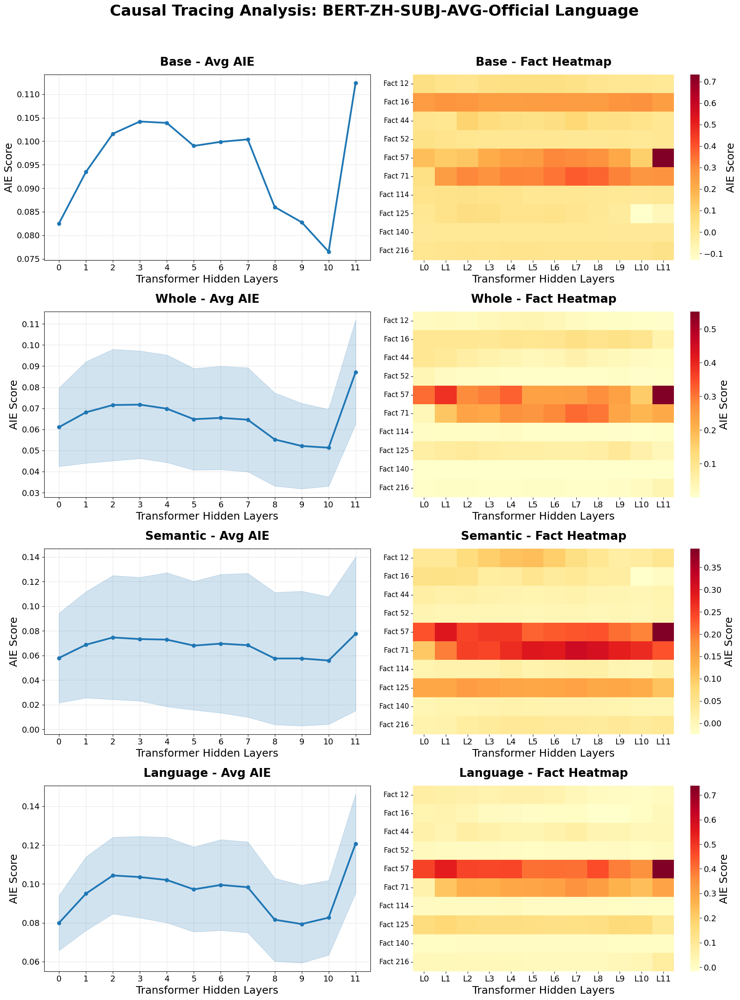

In [8]:
viz.plot_causal_family_grid_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
    random_fact_count=10
)

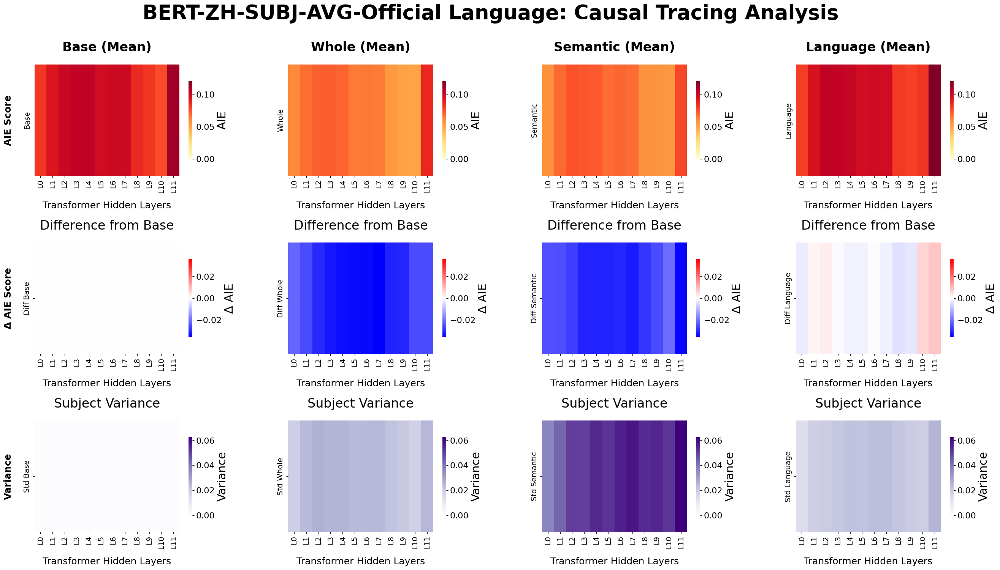

In [9]:

viz.plot_causal_family_overall_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
)

In [10]:
fact_type = "Place of Birth"
family = "BERT-ZH"
avg_analyzers = viz.build_subject_avg_causal_analyzers(subjects, fact_type, family, verbose=True)
print(avg_analyzers.keys())

Subject COL: causal_tracing_results/subject_COL/Place of Birth/BERT-ZH
  causal_BERT-ZH_Language_Place of Birth_ns0.5_n5.pkl → Language
  causal_BERT-ZH_Base_Place of Birth_ns0.5_n5.pkl → Base
  causal_BERT-ZH_Whole_Place of Birth_ns0.5_n5.pkl → Whole
  causal_BERT-ZH_Semantic_Place of Birth_ns0.5_n5.pkl → Semantic
Subject GFW: causal_tracing_results/subject_GFW/Place of Birth/BERT-ZH
  causal_BERT-ZH_Language_Place of Birth_ns0.5_n5.pkl → Language
  causal_BERT-ZH_Base_Place of Birth_ns0.5_n5.pkl → Base
  causal_BERT-ZH_Whole_Place of Birth_ns0.5_n5.pkl → Whole
  causal_BERT-ZH_Semantic_Place of Birth_ns0.5_n5.pkl → Semantic
Subject JUS: causal_tracing_results/subject_JUS/Place of Birth/BERT-ZH
  causal_BERT-ZH_Language_Place of Birth_ns0.5_n5.pkl → Language
  causal_BERT-ZH_Base_Place of Birth_ns0.5_n5.pkl → Base
  causal_BERT-ZH_Whole_Place of Birth_ns0.5_n5.pkl → Whole
  causal_BERT-ZH_Semantic_Place of Birth_ns0.5_n5.pkl → Semantic
Subject KOP: causal_tracing_results/subject_KOP/P

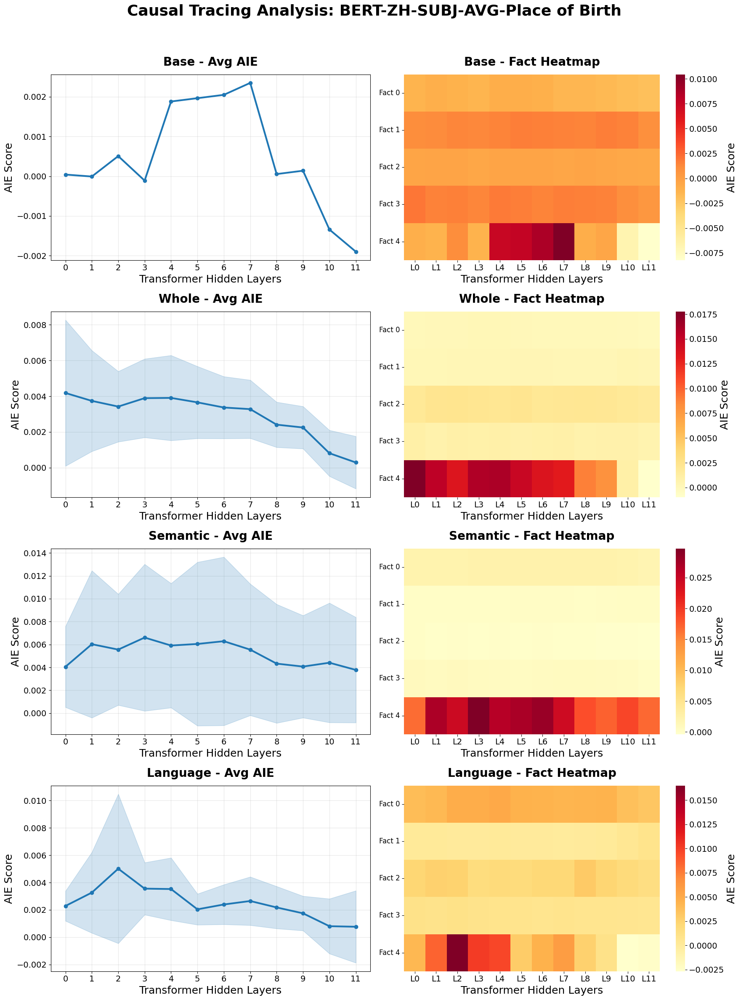

In [11]:
viz.plot_causal_family_grid_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
    random_fact_count=10
)

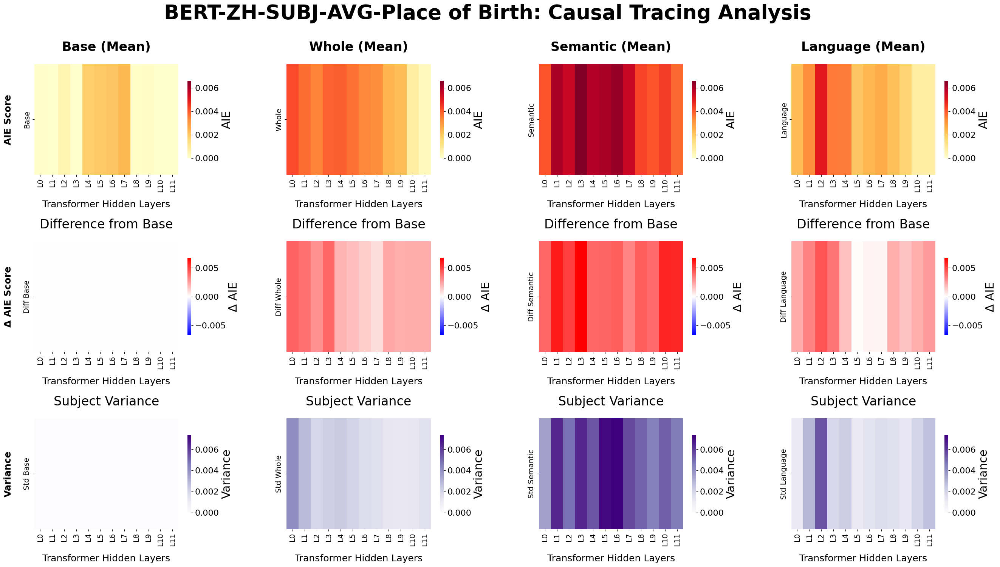

In [12]:

viz.plot_causal_family_overall_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
)

In [13]:
fact_type = "Continent"
family = "BERT-ZH"
avg_analyzers = viz.build_subject_avg_causal_analyzers(subjects, fact_type, family, verbose=True)
print(avg_analyzers.keys())

Subject COL: causal_tracing_results/subject_COL/Continent/BERT-ZH
  causal_BERT-ZH_Semantic_Continent_ns0.5_n21.pkl → Semantic
  causal_BERT-ZH_Base_Continent_ns0.5_n21.pkl → Base
  causal_BERT-ZH_Language_Continent_ns0.5_n21.pkl → Language
  causal_BERT-ZH_Whole_Continent_ns0.5_n21.pkl → Whole
Subject GFW: causal_tracing_results/subject_GFW/Continent/BERT-ZH
  causal_BERT-ZH_Semantic_Continent_ns0.5_n21.pkl → Semantic
  causal_BERT-ZH_Base_Continent_ns0.5_n21.pkl → Base
  causal_BERT-ZH_Language_Continent_ns0.5_n21.pkl → Language
  causal_BERT-ZH_Whole_Continent_ns0.5_n21.pkl → Whole
Subject JUS: causal_tracing_results/subject_JUS/Continent/BERT-ZH
  causal_BERT-ZH_Semantic_Continent_ns0.5_n21.pkl → Semantic
  causal_BERT-ZH_Base_Continent_ns0.5_n21.pkl → Base
  causal_BERT-ZH_Language_Continent_ns0.5_n21.pkl → Language
  causal_BERT-ZH_Whole_Continent_ns0.5_n21.pkl → Whole
Subject KOP: causal_tracing_results/subject_KOP/Continent/BERT-ZH
  causal_BERT-ZH_Semantic_Continent_ns0.5_n21.

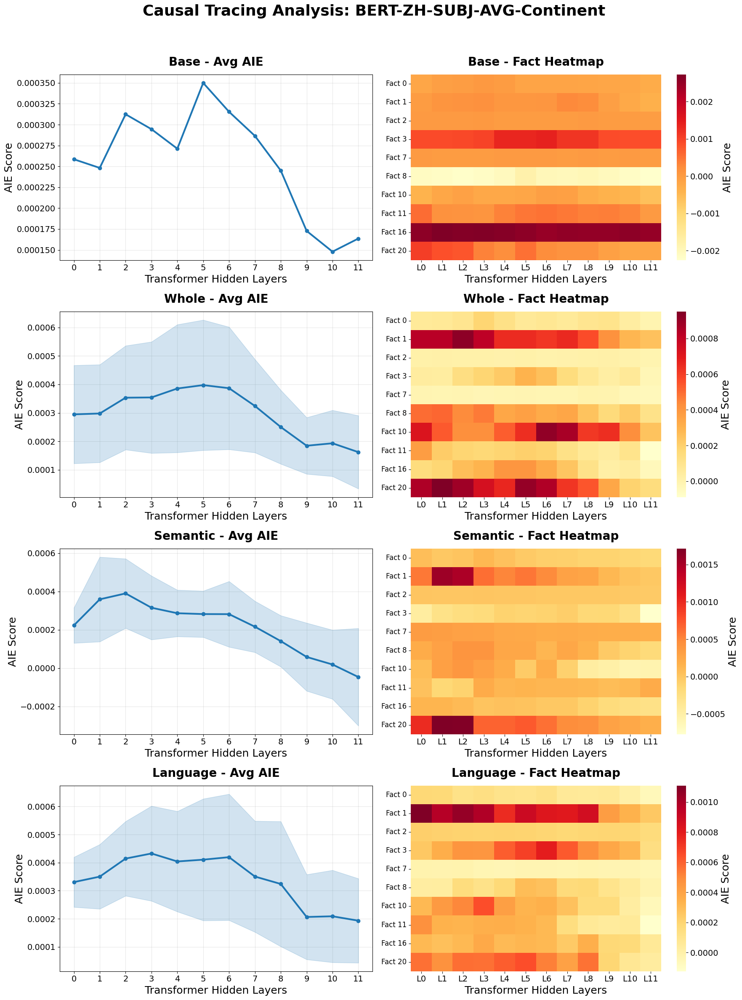

In [14]:
viz.plot_causal_family_grid_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
    random_fact_count=10
)

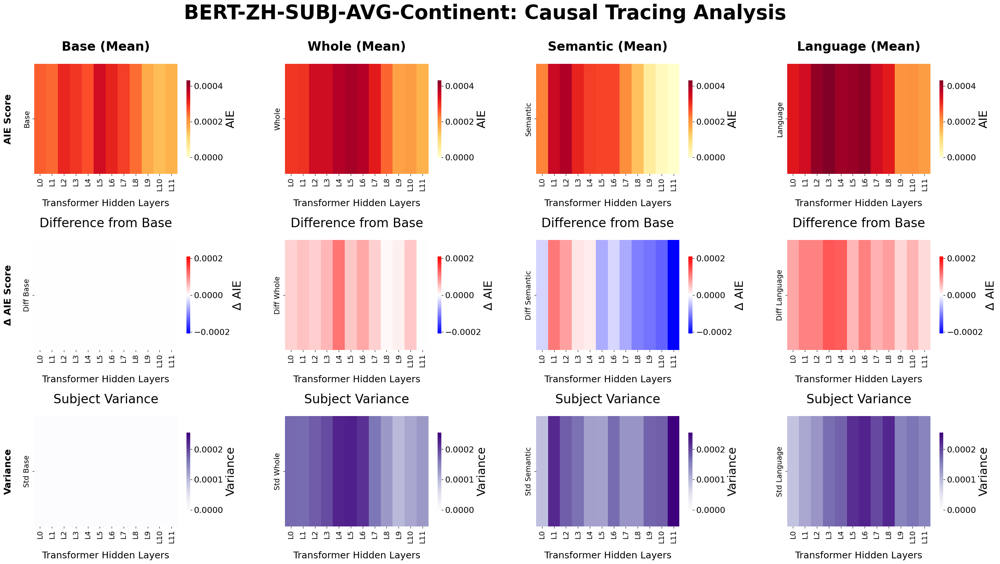

In [15]:

viz.plot_causal_family_overall_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
)

In [16]:
fact_type = "Developer"
family = "BERT-ZH"
avg_analyzers = viz.build_subject_avg_causal_analyzers(subjects, fact_type, family, verbose=True)
print(avg_analyzers.keys())

Subject COL: causal_tracing_results/subject_COL/Developer/BERT-ZH
  causal_BERT-ZH_Whole_Developer_ns0.5_n89.pkl → Whole
  causal_BERT-ZH_Language_Developer_ns0.5_n89.pkl → Language
  causal_BERT-ZH_Semantic_Developer_ns0.5_n89.pkl → Semantic
  causal_BERT-ZH_Base_Developer_ns0.5_n89.pkl → Base
Subject GFW: causal_tracing_results/subject_GFW/Developer/BERT-ZH
  causal_BERT-ZH_Whole_Developer_ns0.5_n89.pkl → Whole
  causal_BERT-ZH_Language_Developer_ns0.5_n89.pkl → Language
  causal_BERT-ZH_Semantic_Developer_ns0.5_n89.pkl → Semantic
  causal_BERT-ZH_Base_Developer_ns0.5_n89.pkl → Base
Subject JUS: causal_tracing_results/subject_JUS/Developer/BERT-ZH
  causal_BERT-ZH_Whole_Developer_ns0.5_n89.pkl → Whole
  causal_BERT-ZH_Language_Developer_ns0.5_n89.pkl → Language
  causal_BERT-ZH_Semantic_Developer_ns0.5_n89.pkl → Semantic
  causal_BERT-ZH_Base_Developer_ns0.5_n89.pkl → Base
Subject KOP: causal_tracing_results/subject_KOP/Developer/BERT-ZH
  causal_BERT-ZH_Whole_Developer_ns0.5_n89.pkl

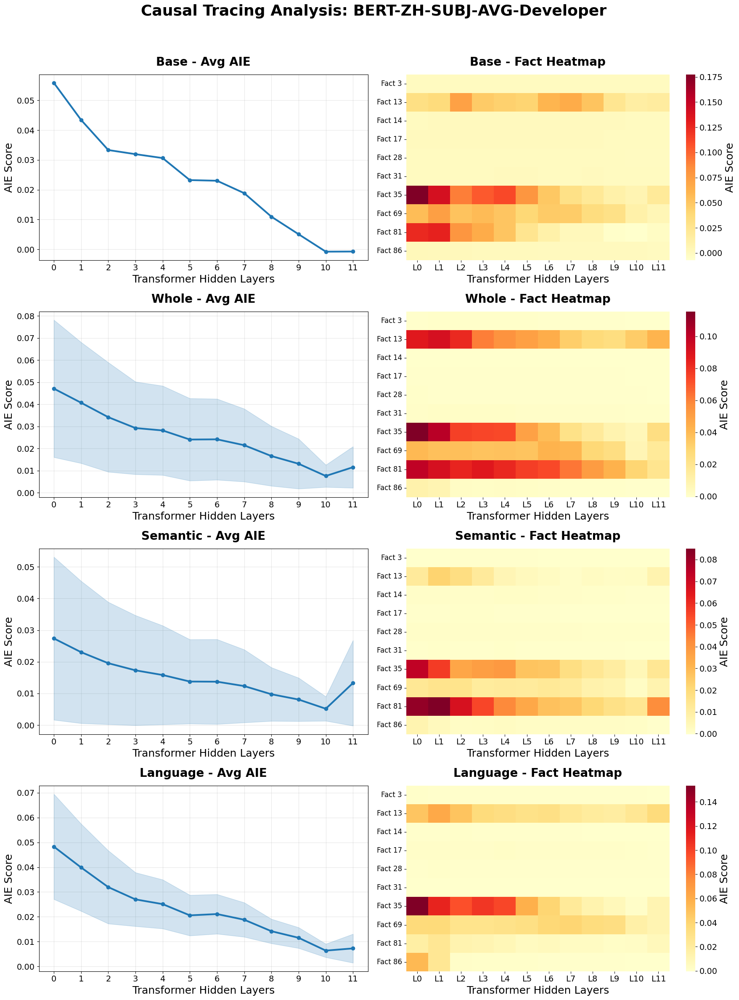

In [17]:
viz.plot_causal_family_grid_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
    random_fact_count=10
)

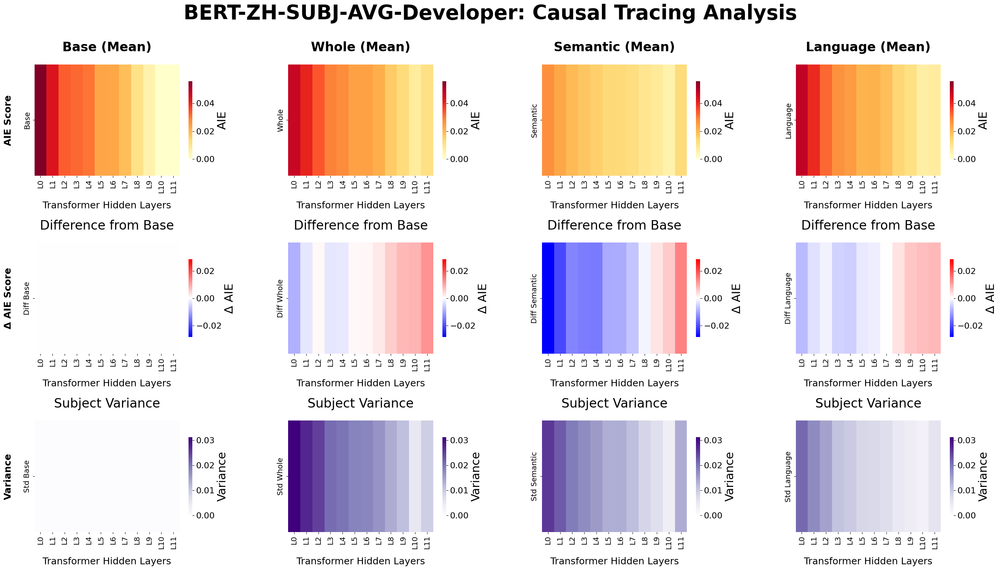

In [18]:

viz.plot_causal_family_overall_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
)

# mBERT-ZH

In [3]:
fact_type = "Capital"
family = "mBERT-ZH"

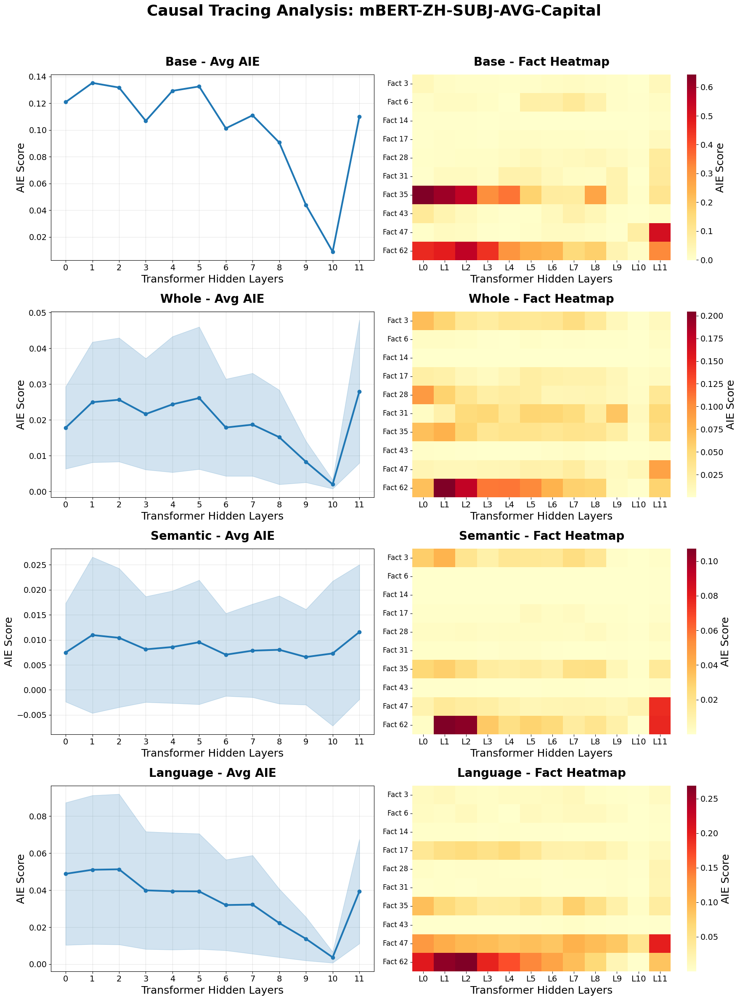

In [4]:
viz.plot_causal_family_grid_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
    random_fact_count=10
)

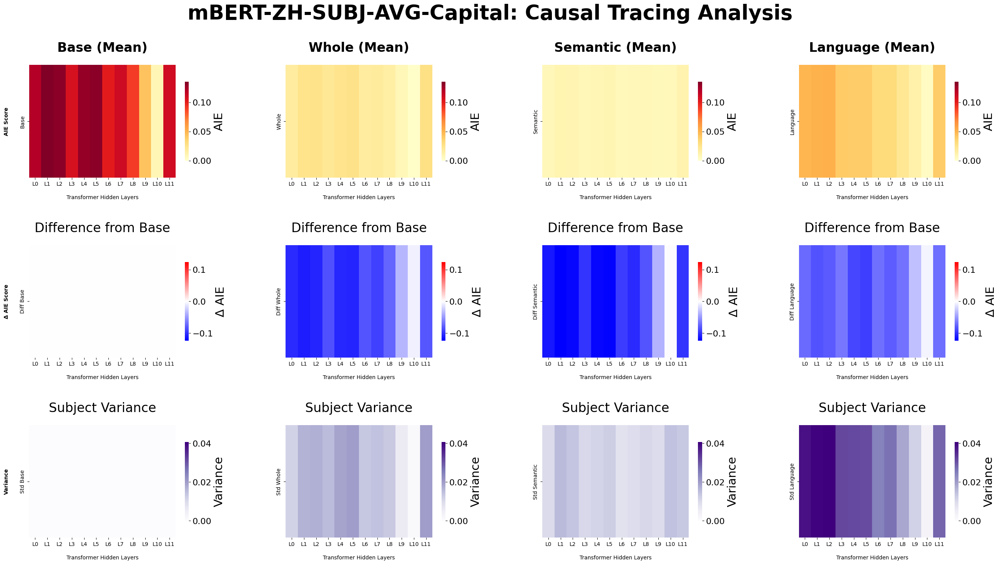

In [4]:

viz.plot_causal_family_overall_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
)

In [3]:
fact_type = "Official Language"
family = "mBERT-ZH"

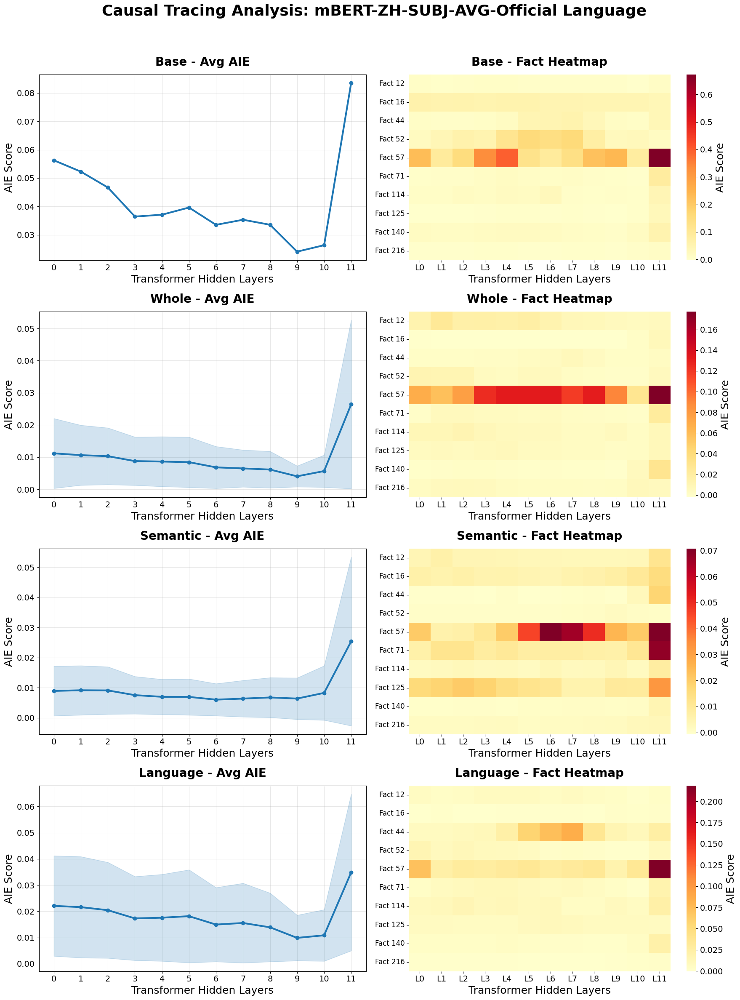

In [4]:
viz.plot_causal_family_grid_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
    random_fact_count=10
)

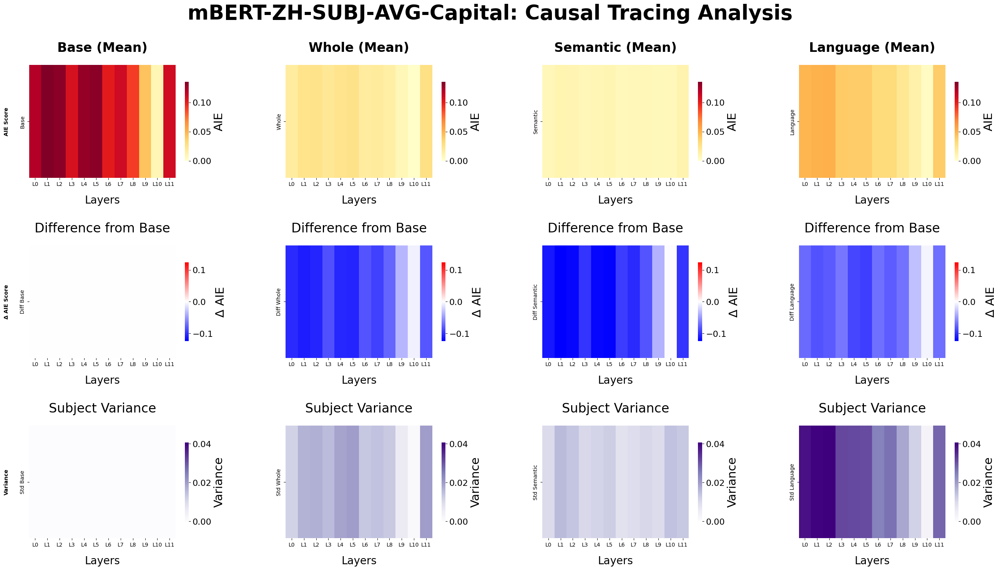

In [4]:

viz.plot_causal_family_overall_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
)

In [3]:
fact_type = "Place of Birth"
family = "mBERT-ZH"

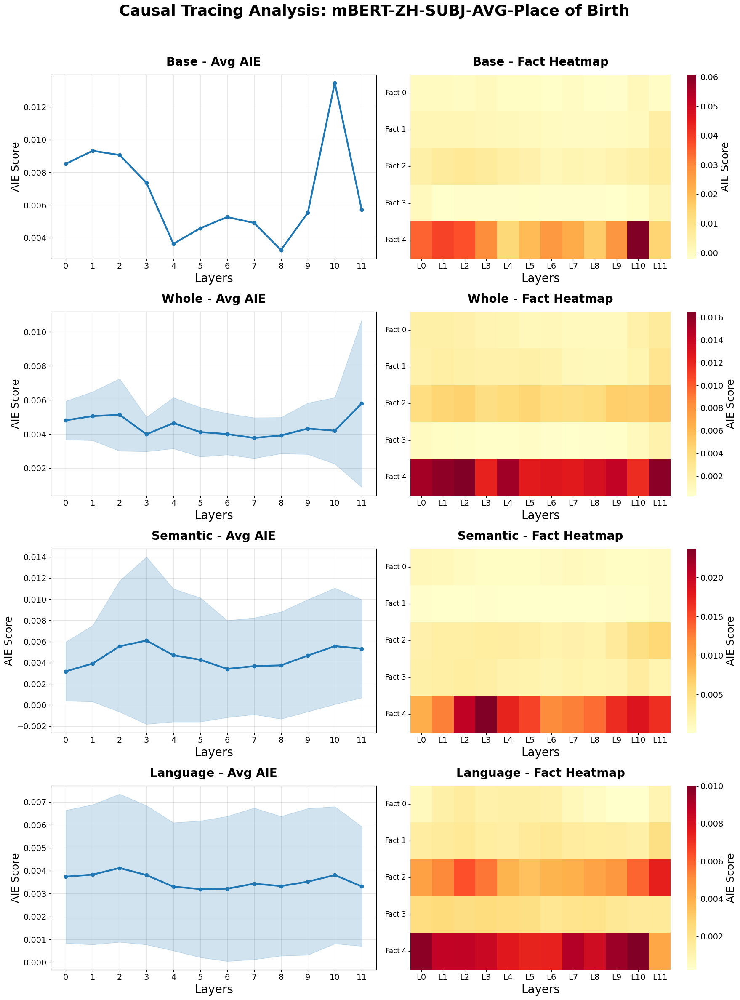

In [4]:
viz.plot_causal_family_grid_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
    random_fact_count=10
)

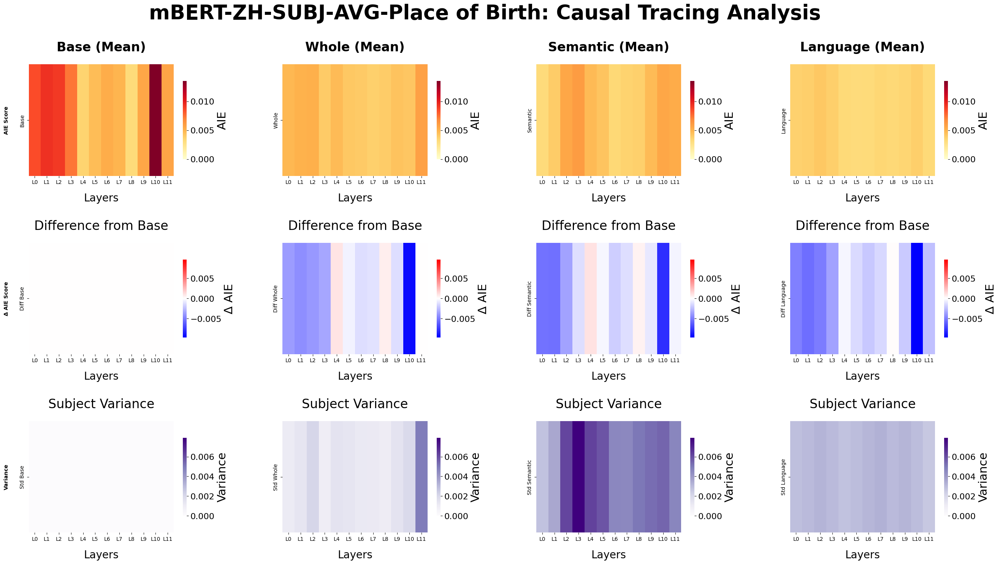

In [4]:

viz.plot_causal_family_overall_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
)

In [3]:
fact_type = "Continent"
family = "mBERT-ZH"

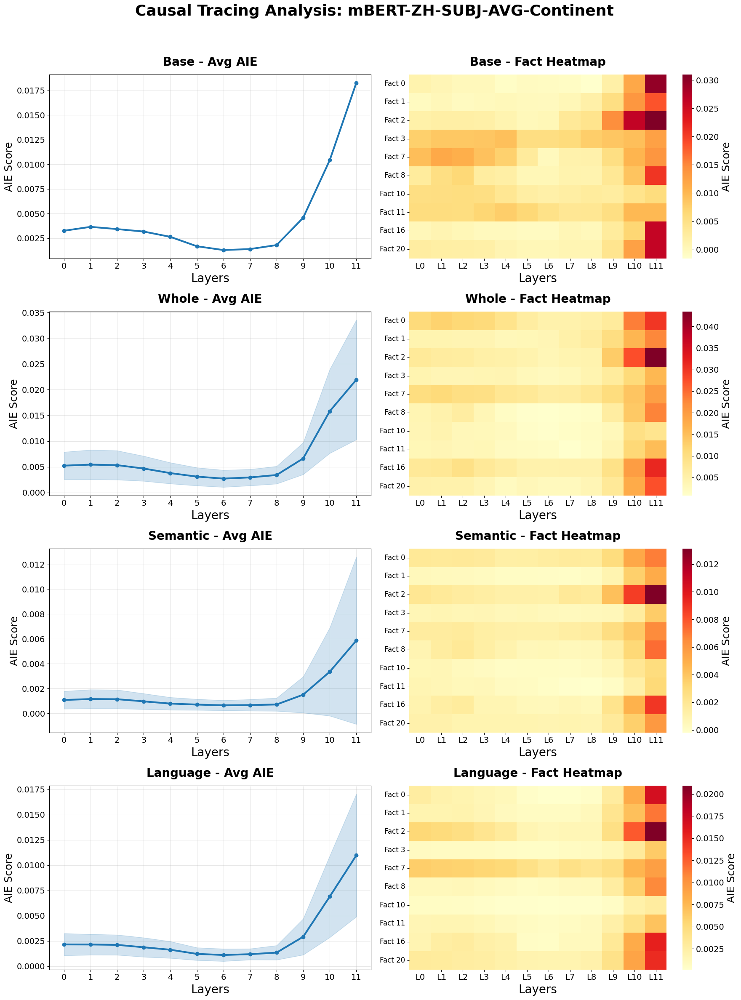

In [4]:
viz.plot_causal_family_grid_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
    random_fact_count=10
)

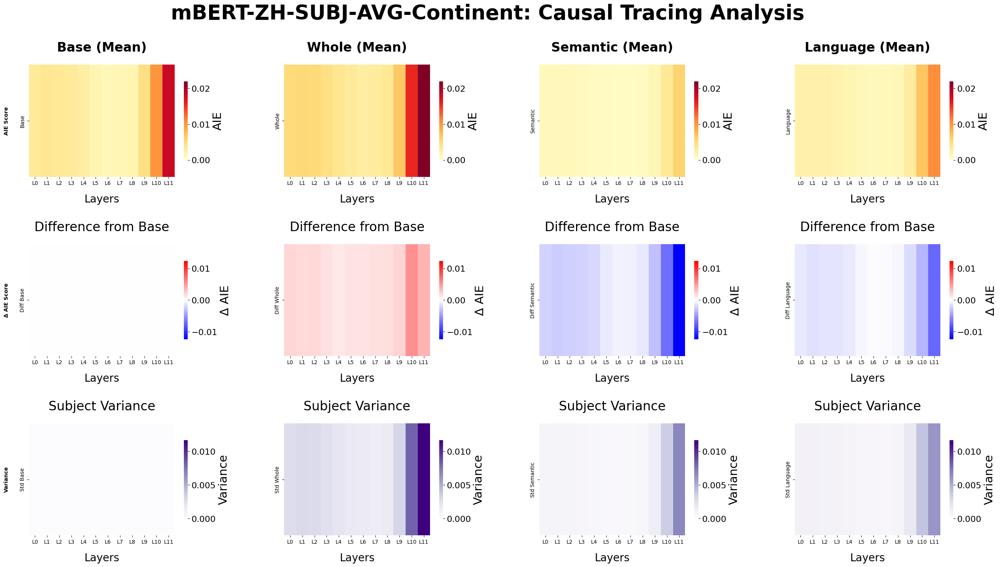

In [4]:

viz.plot_causal_family_overall_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
)

In [3]:
fact_type = "Developer"
family = "mBERT-ZH"
avg_analyzers = viz.build_subject_avg_causal_analyzers(subjects, fact_type, family, verbose=True)
print(avg_analyzers.keys())

Subject COL: causal_tracing_results/subject_COL/Developer/mBERT-ZH
  causal_mBERT-ZH_Whole_Developer_ns0.5_n89.pkl → Whole
  causal_mBERT-ZH_Semantic_Developer_ns0.5_n89.pkl → Semantic
  causal_mBERT-ZH_Base_Developer_ns0.5_n89.pkl → Base
  causal_mBERT-ZH_Language_Developer_ns0.5_n89.pkl → Language
Subject GFW: causal_tracing_results/subject_GFW/Developer/mBERT-ZH
  causal_mBERT-ZH_Whole_Developer_ns0.5_n89.pkl → Whole
  causal_mBERT-ZH_Semantic_Developer_ns0.5_n89.pkl → Semantic
  causal_mBERT-ZH_Base_Developer_ns0.5_n89.pkl → Base
  causal_mBERT-ZH_Language_Developer_ns0.5_n89.pkl → Language
Subject JUS: causal_tracing_results/subject_JUS/Developer/mBERT-ZH
  causal_mBERT-ZH_Whole_Developer_ns0.5_n89.pkl → Whole
  causal_mBERT-ZH_Semantic_Developer_ns0.5_n89.pkl → Semantic
  causal_mBERT-ZH_Base_Developer_ns0.5_n89.pkl → Base
  causal_mBERT-ZH_Language_Developer_ns0.5_n89.pkl → Language
Subject KOP: causal_tracing_results/subject_KOP/Developer/mBERT-ZH
  causal_mBERT-ZH_Whole_Develo

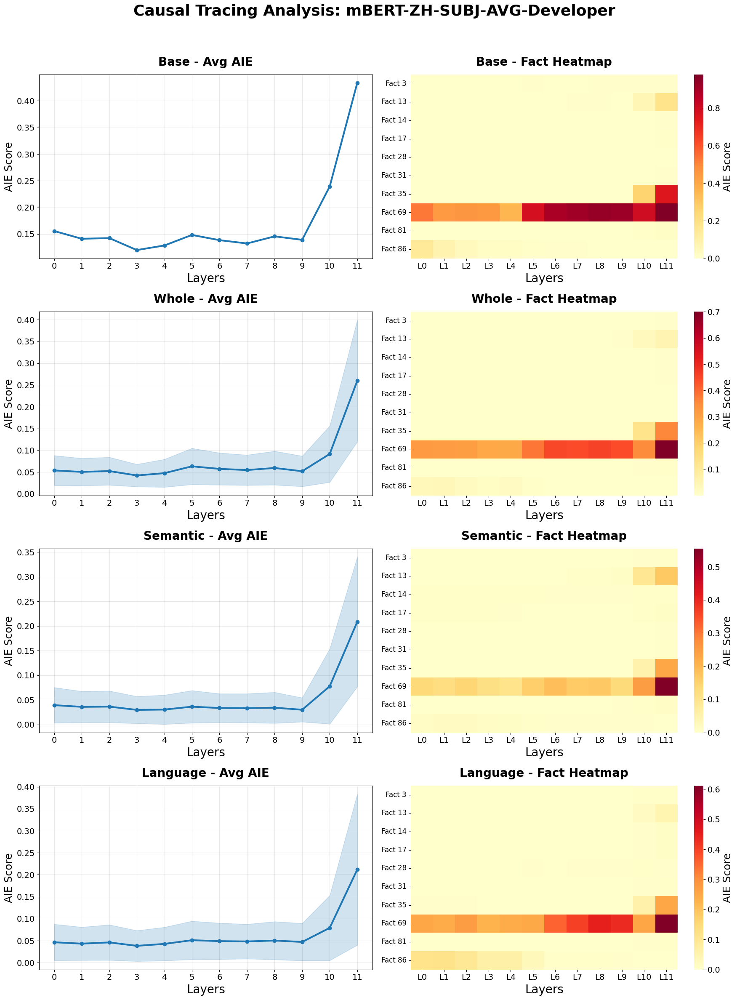

In [4]:
viz.plot_causal_family_grid_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
    random_fact_count=10
)

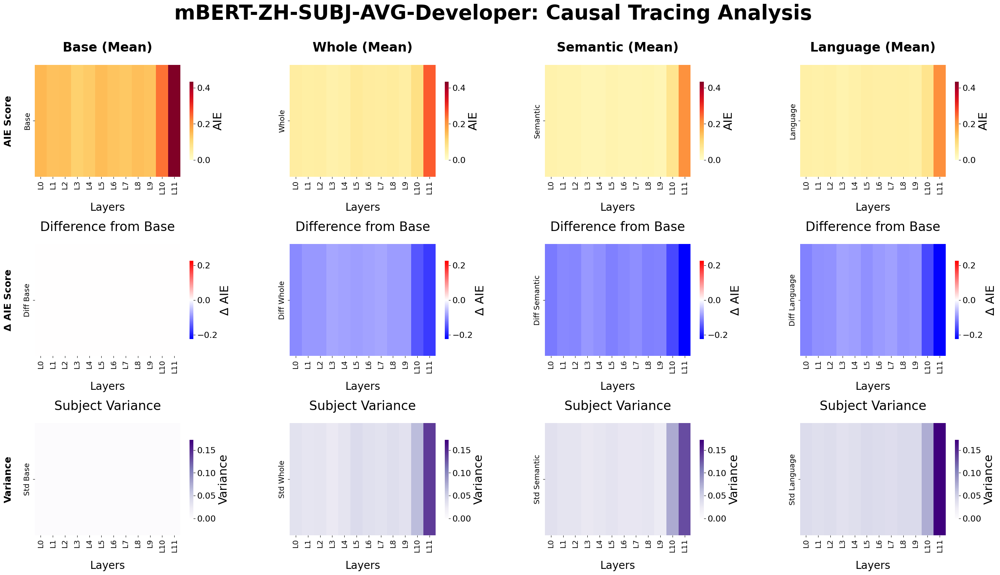

In [5]:

viz.plot_causal_family_overall_subject_avg(
    subjects=subjects,
    fact_type=fact_type,
    family_name=family,
)